EDA и разверточный анализ

In [22]:
pip install pandas scipy liac-arff matplotlib seaborn scikit-learn dvc


Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import os
from scipy.io.arff import loadarff
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [24]:
file_path = "../data/raw/dataset"
data, meta = loadarff(file_path)

# Преобразуем в DataFrame
df = pd.DataFrame(data)
print(df.head())

# Исходные суммы до любых преобразований (для проверки гипотезы)
df["Amount_original"] = df["Amount"].copy()


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [39]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 252903 entries, 0 to 284805
Data columns (total 32 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Time        252903 non-null  float64
 1   V1          252903 non-null  float64
 2   V2          252903 non-null  float64
 3   V3          252903 non-null  float64
 4   V4          252903 non-null  float64
 5   V5          252903 non-null  float64
 6   V6          252903 non-null  float64
 7   V7          252903 non-null  float64
 8   V8          252903 non-null  float64
 9   V9          252903 non-null  float64
 10  V10         252903 non-null  float64
 11  V11         252903 non-null  float64
 12  V12         252903 non-null  float64
 13  V13         252903 non-null  float64
 14  V14         252903 non-null  float64
 15  V15         252903 non-null  float64
 16  V16         252903 non-null  float64
 17  V17         252903 non-null  float64
 18  V18         252903 non-null  float64
 19  V19         252903

In [26]:
print(df["Class"].value_counts(normalize=True))

Class
0.0    0.998273
1.0    0.001727
Name: proportion, dtype: float64


Сильный дисбаланс классов

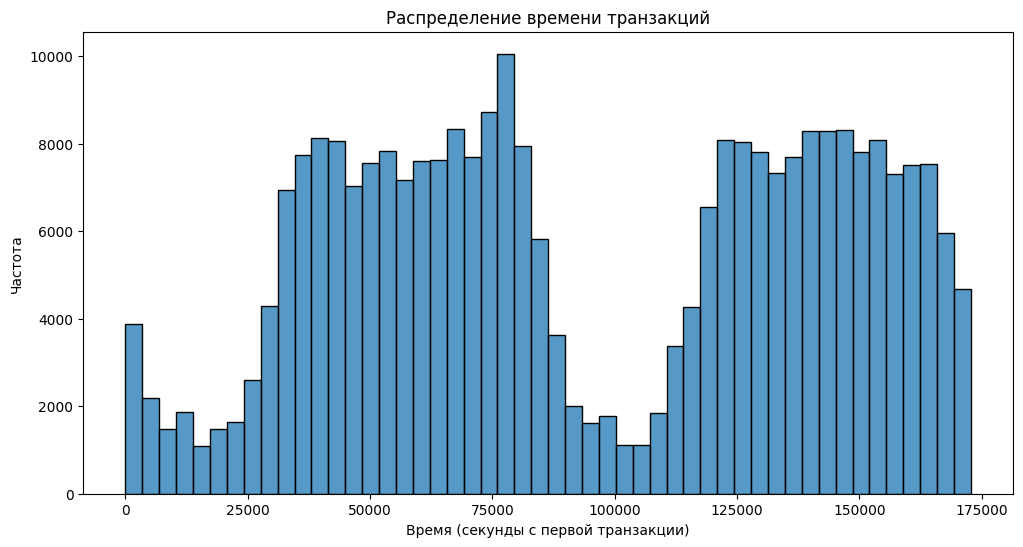

In [27]:
plt.figure(figsize=(12, 6))
sns.histplot(df["Time"], bins=50)
plt.title("Распределение времени транзакций")
plt.xlabel("Время (секунды с первой транзакции)")
plt.ylabel("Частота")
plt.show()

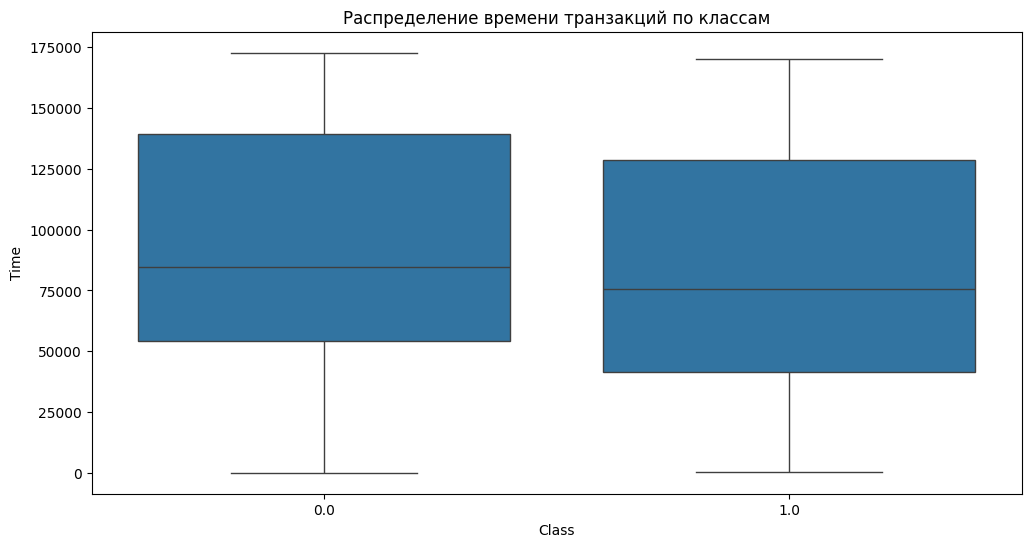

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Class", y="Time", data=df)
plt.title("Распределение времени транзакций по классам")
plt.show()


Нет явных временных интервалов, где мошенничество происходит чаще

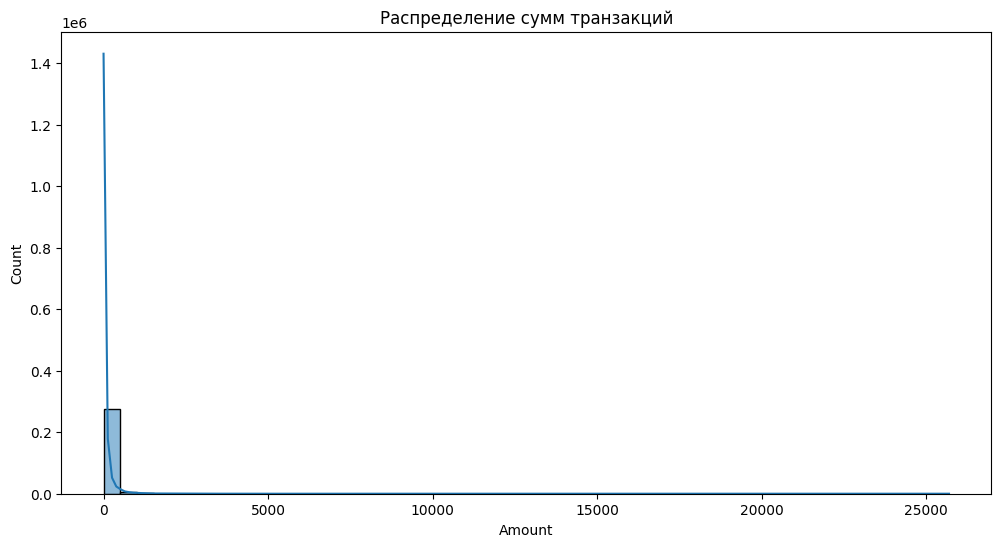

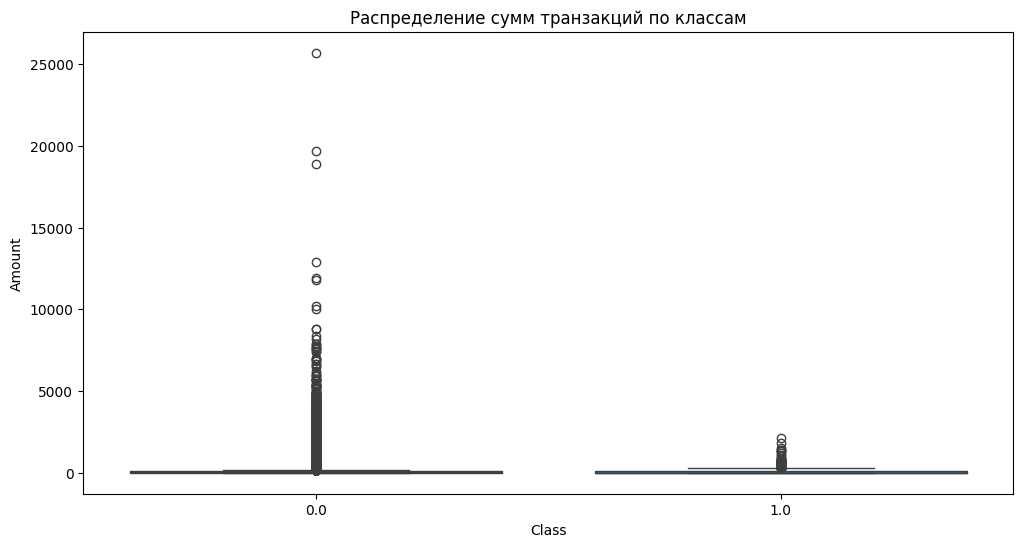

In [29]:
plt.figure(figsize=(12, 6))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Распределение сумм транзакций")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Распределение сумм транзакций по классам")
plt.show()


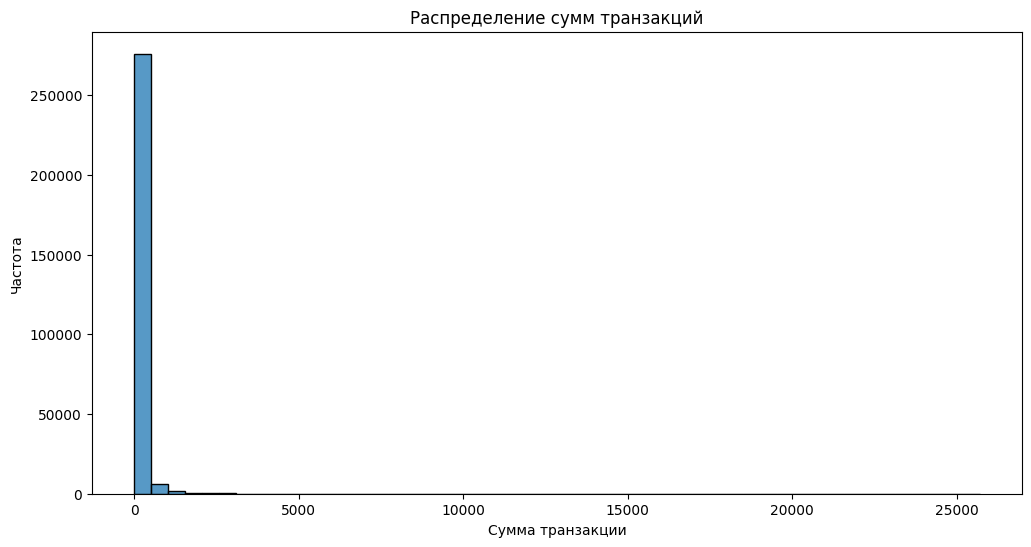

In [30]:
plt.figure(figsize=(12, 6))
sns.histplot(df["Amount"], bins=50)
plt.title("Распределение сумм транзакций")
plt.xlabel("Сумма транзакции")
plt.ylabel("Частота")
plt.show()


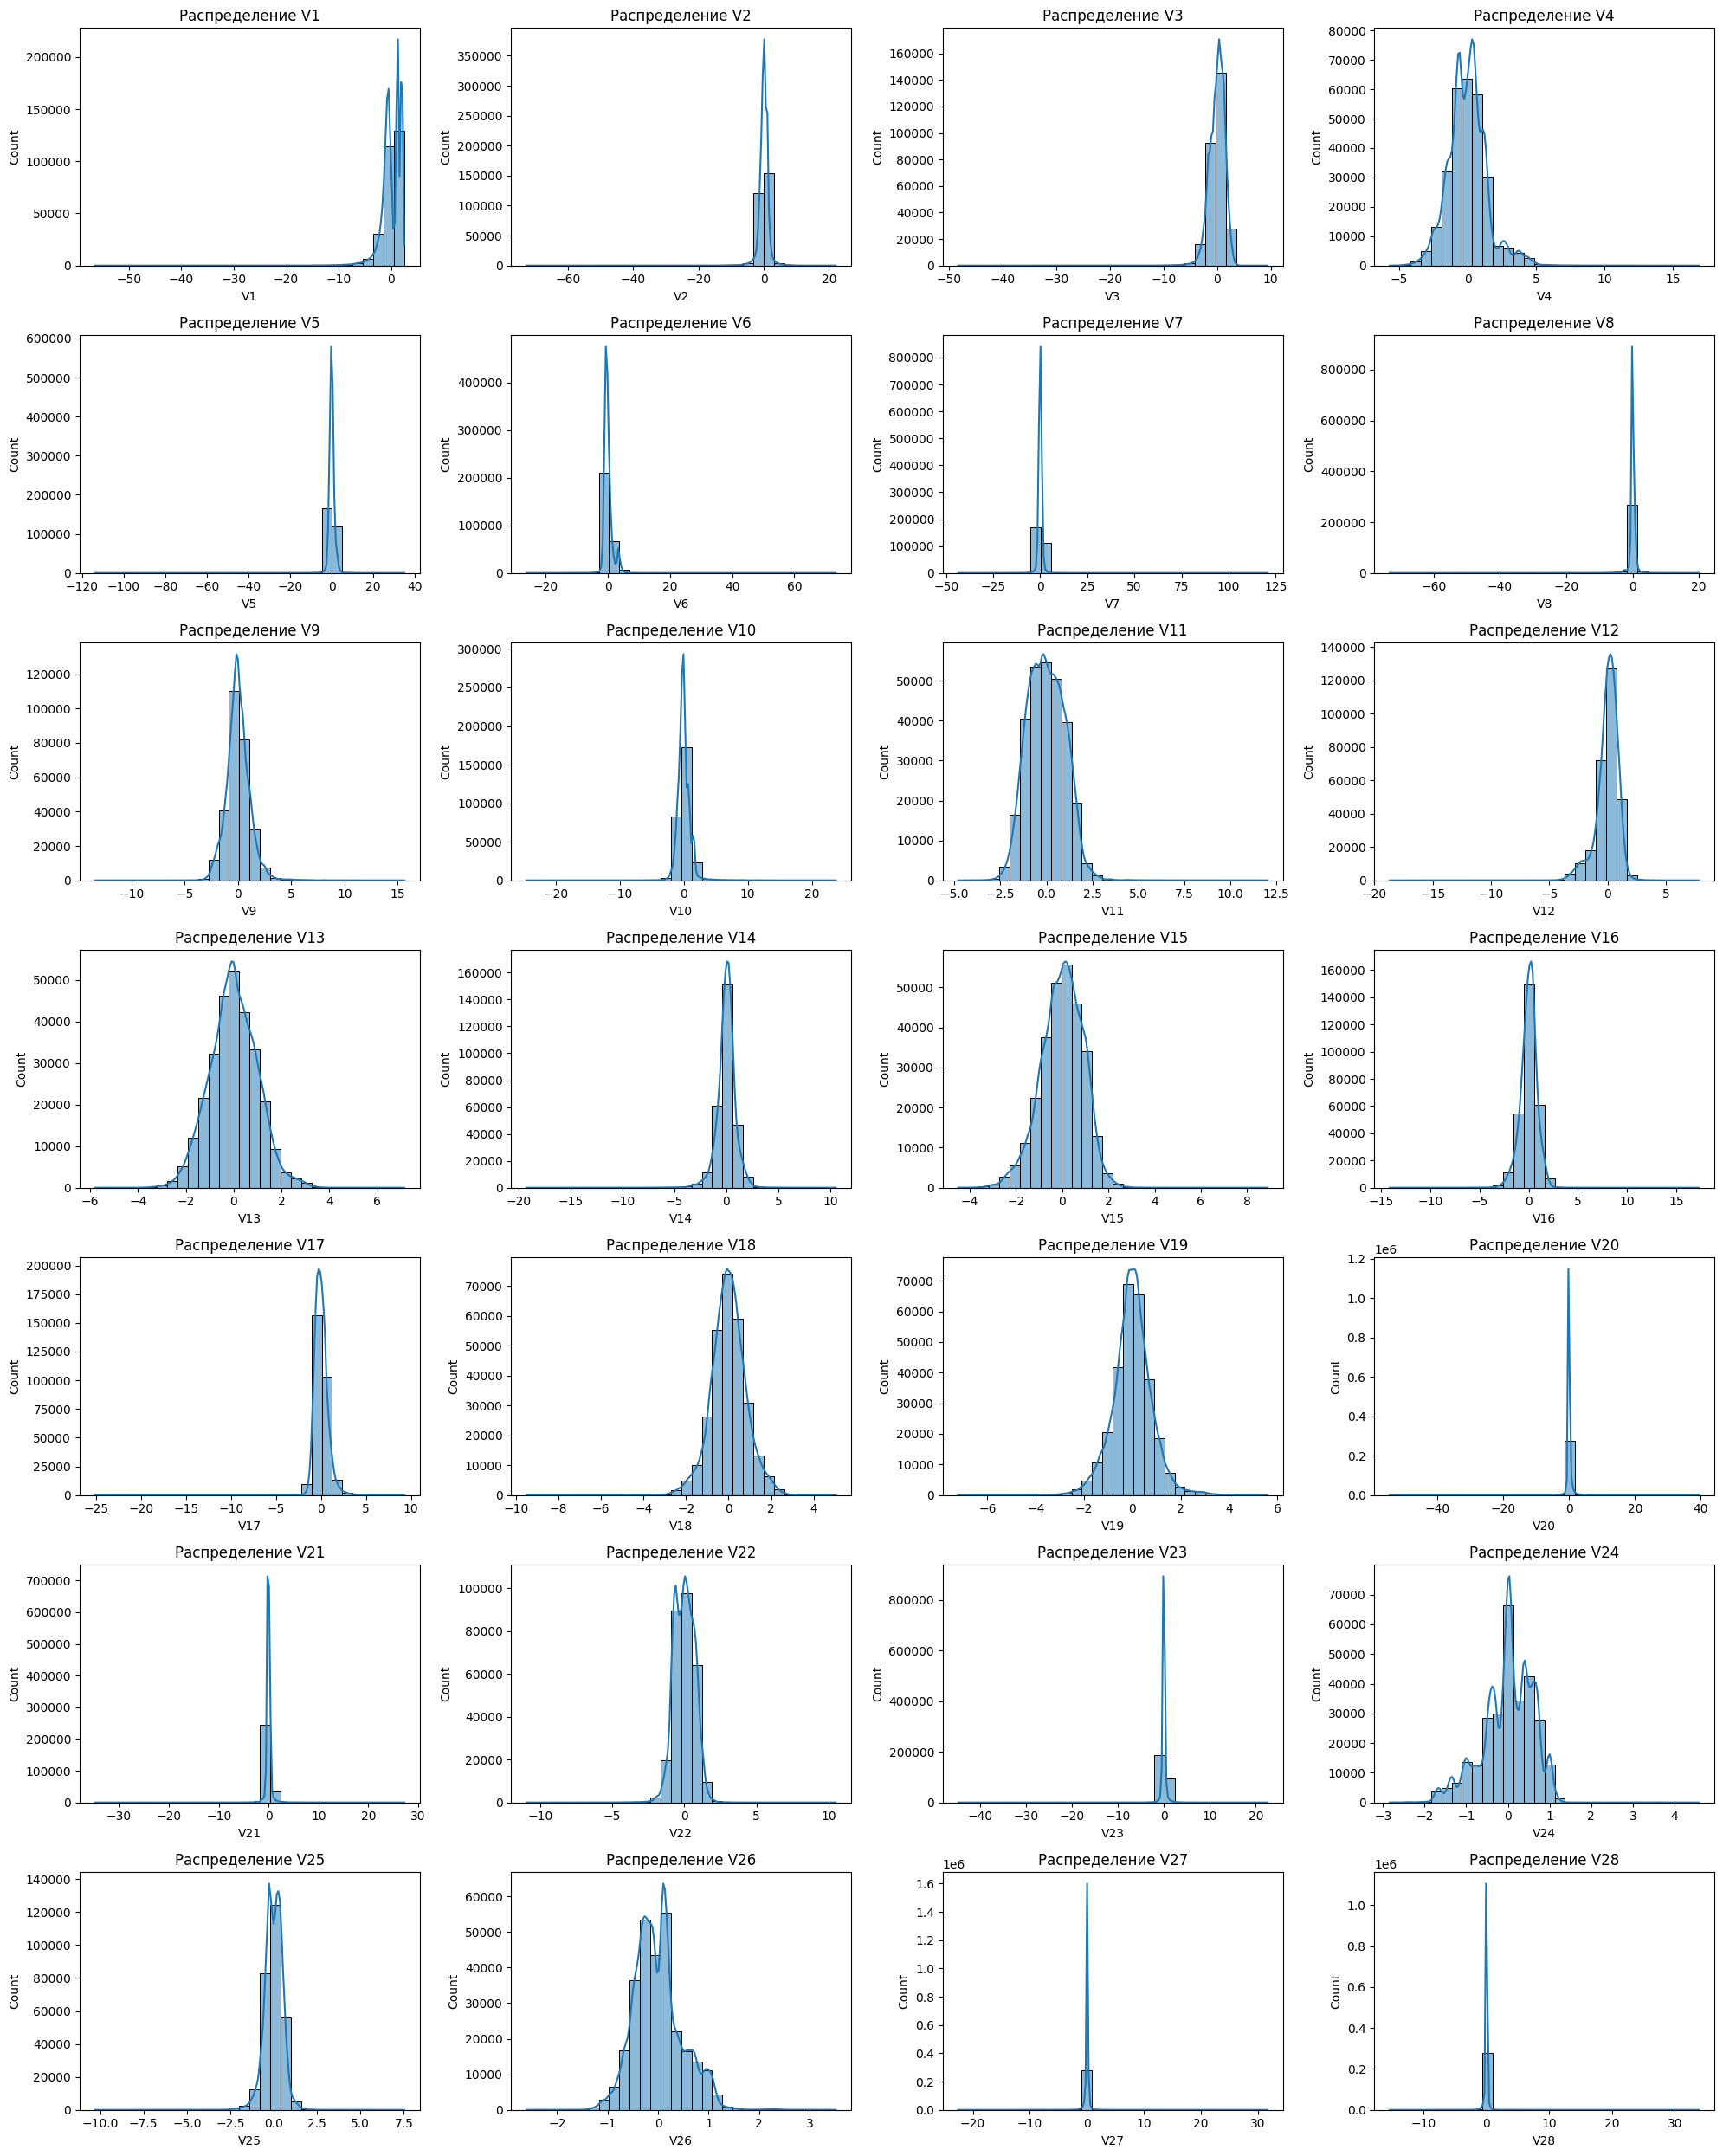

In [31]:
fig, axes = plt.subplots(7, 4, figsize=(20, 25))
axes = axes.flatten()  # Преобразуем в одномерный массив для удобства

# Строим гистограммы для каждого признака V1-V28
for i, col in enumerate(df.columns[1:29]):  # Берем только V1-V28
    sns.histplot(df[col], ax=axes[i], bins=30, kde=True)
    axes[i].set_title(f"Распределение {col}")

# Убираем пустые подграфики (если они есть)
for j in range(28, len(axes)):
    axes[j].axis('off')

plt.tight_layout()  # Чтобы графики не накладывались
plt.show()

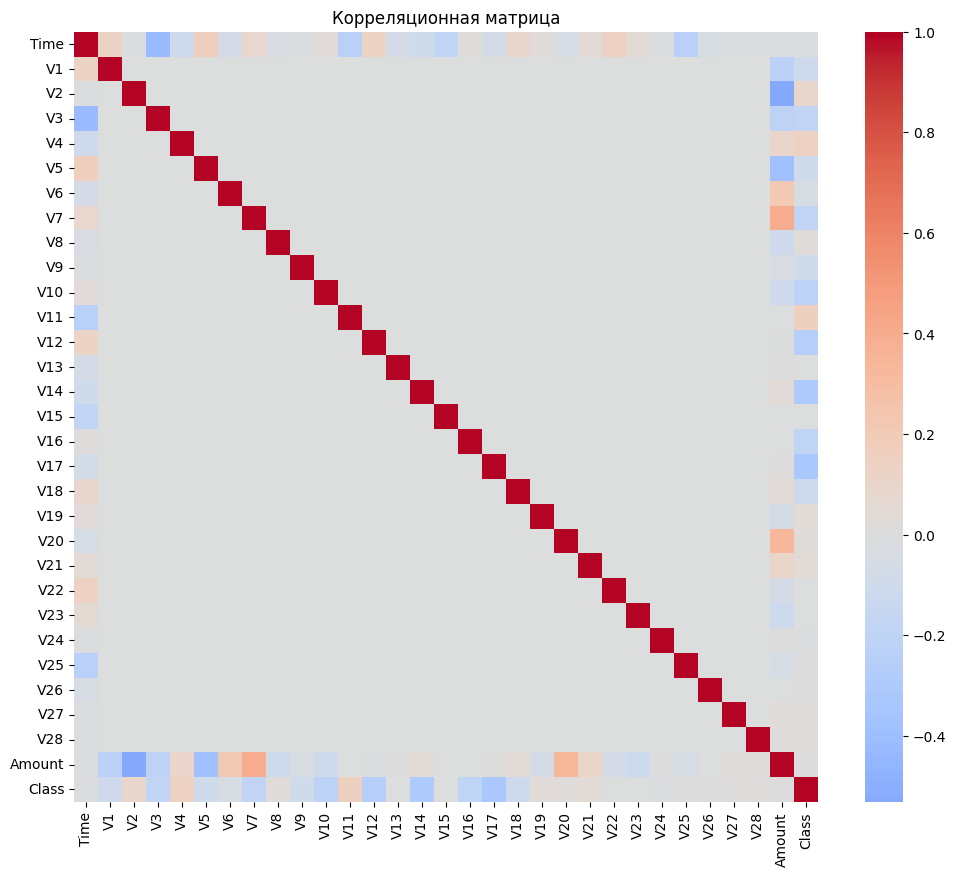

In [32]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Корреляционная матрица")
plt.show()


Признаки не коррелируют друг с другом, что хорошо для моделей

БЦ:
снижение финансовых потерь от фрода

миниизация ложных срабатываний

автоматизация процесса

recall>=90%
precision>=70%
f1-score>=0.8

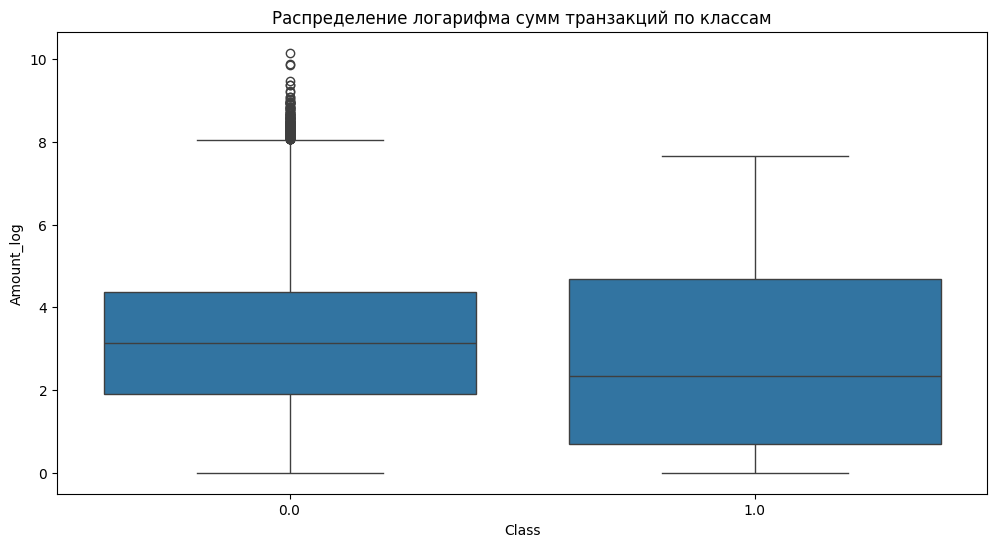

In [33]:
df['Amount_log'] = np.log1p(df['Amount'])

plt.figure(figsize=(12, 6))
sns.boxplot(x="Class", y="Amount_log", data=df)
plt.title("Распределение логарифма сумм транзакций по классам")
plt.show()


In [34]:
# Проверка гипотезы: fraud на мелких суммах (исходные суммы)
amt_col = "Amount_original" if "Amount_original" in df.columns else "Amount"
display(df.groupby("Class")[amt_col].describe())


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1.0,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [40]:
amt_col = "Amount_original" if "Amount_original" in df.columns else "Amount"
for thr in [10, 50, 100]:
    fraud_small = ((df["Class"] == 1.0) & (df[amt_col] <= thr)).sum()
    fraud_total = (df["Class"] == 1.0).sum()
    all_small = (df[amt_col] <= thr).sum()
    all_total = len(df)
    frac_fraud_small = fraud_small / fraud_total if fraud_total > 0 else 0
    frac_all_small = all_small / all_total if all_total > 0 else 0
    print(
        f"Порог {thr}: "
        f"{frac_fraud_small:.2%} всех fraud-транзакций с суммой ≤ {thr}, "
        f"{frac_all_small:.2%} всех транзакций с суммой ≤ {thr}"
    )

Порог 10: 100.00% всех fraud-транзакций с суммой ≤ 10, 100.00% всех транзакций с суммой ≤ 10
Порог 50: 100.00% всех fraud-транзакций с суммой ≤ 50, 100.00% всех транзакций с суммой ≤ 50
Порог 100: 100.00% всех fraud-транзакций с суммой ≤ 100, 100.00% всех транзакций с суммой ≤ 100


**Вывод по гипотезе.** Используем **исходные** суммы (`Amount_original`), чтобы не зависеть от порядка ячеек (IQR, масштабирование).

- По **медиане** и **25% квантилю** вывод **корректен**: у fraud медиана 9.25 €, 25% = 1 €; у обычных — 22 € и 5.65 €. Типичные мошеннические транзакции действительно на меньших суммах.
- По **среднему (mean)** картина иная: у fraud mean 122.21 €, у обычных 88.29 € — у fraud выше из‑за правого хвоста (отдельные крупные суммы). Поэтому формулировать стоит именно про **медиану/типичные суммы**, а не «в среднем» в смысле mean.

**Итог:** вывод «мошеннические транзакции на меньших суммах» по этим данным валидная гипотеза; по среднему арифметическому — не валидная (у fraud оно выше).